<div class="usecase-title">Urban Bike-Sharing Demand Prediction with Graph Learning</div>

<div class="usecase-authors"><b>Authored by: </b> Sanaullah</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, NumPy, matplotlib, scikit-learn, NetworkX, time-series feature engineering, regression model evaluation</div>
</div>

<div class="usecase-section-header">Scenario</div>

As a transport operations analyst, I want to predict short-term bike availability and empty dock availability across Melbourne bike-share stations, so that rebalancing decisions can be supported by evidence rather than manual inspection alone.

This use case applies graph-aware machine learning to historical station readings. The workflow treats stations as a connected network, builds time-based and station-neighbourhood features, compares non-graph and graph-aware forecasting models, and produces operational risk outputs that identify stations and hours most likely to need intervention.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will be able to:

- Prepare station-level bike-share readings as a regular hourly time-series dataset.
- Engineer lag, rolling, calendar, and operational pressure features for demand prediction.
- Create multi-horizon supervised learning targets for 1-hour, 3-hour, and 6-hour forecasting.
- Build a station graph using geographic proximity and analyse graph connectivity.
- Add graph-derived features that represent neighbouring station availability and pressure.
- Train and compare baseline, non-graph, and graph-aware forecasting models.
- Evaluate model performance using MAE and RMSE for bike availability and empty dock availability.
- Convert model outputs into operational risk rankings for station rebalancing decisions.

<div class="usecase-section-header">Introduction and background</div>

Bike-share systems are operationally challenging because demand changes by location, hour of day, and surrounding station conditions. A station may become unusable if it has too few bikes for departures or too few empty docks for returns. Traditional forecasting can model each station using its own historical behaviour, but bike-share stations are also spatially connected: pressure at one station can relate to pressure at nearby stations.

This notebook uses the Melbourne Bike Share station readings dataset from the City of Melbourne open data portal. The workflow focuses on three practical use cases: predicting future bike availability, predicting future empty dock availability, and identifying recurring demand-pressure patterns across the station network. The final approach compares non-graph baselines with graph-aware models so the reader can see whether adding neighbourhood information improves operational forecasting.

<div class="usecase-section-header">Dataset and execution requirements</div>

This notebook expects the cleaned working dataset file named `station_timeseries_clean_with_features.csv` to be placed in the same folder as the notebook. The original raw source is the City of Melbourne open data page for Melbourne bike-share station readings from 2011 to 2017.

Outputs are saved into an `outputs_final` folder, with separate subfolders for tables and figures. Run the notebook from top to bottom so that the configuration, utility functions, prepared features, model targets, graph features, evaluation tables, and final risk outputs are created in the correct order.

<div class="usecase-section-header">Use case workflow</div>

In [4]:
from IPython.core.display import HTML
HTML("""
<style>
.usecase-title, .usecase-duration, .usecase-section-header {
    padding-left: 15px;
    padding-bottom: 10px;
    padding-top: 10px;
    padding-right: 15px;
    background-color: #0f9295;
    color: #fff;
}
.usecase-title { font-size: 1.7em; font-weight: bold; }
.usecase-authors, .usecase-level, .usecase-skill {
    padding-left: 15px; padding-bottom: 10px; padding-top: 10px; padding-right: 15px;
    background-color: #e8e8e8; color: #0f9295;
}
.usecase-duration { font-size: 1.1em; }
.usecase-section-header { font-size: 1.4em; font-weight: bold; margin-top: 20px; }
.usecase-subsection-header { font-weight: bold; font-size: 1.2em; color: #0f9295; margin-top: 15px; }
.usecase-subsection-blurb { font-weight: bold; color: #555; }
</style>
""")

<p class="usecase-subsection-header">1. Imports, configuration, and paths</p>

This section imports the libraries used throughout the notebook and defines portable paths. The notebook expects the cleaned working dataset to be named `station_timeseries_clean_with_features.csv` and placed in the same directory as this notebook.

All final tables and figures are saved into `outputs_final/tables` and `outputs_final/figures`.

In [2]:
# ============================================================
# 1. Imports, configuration, and portable paths
# ============================================================
import os
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "station_timeseries_clean_with_features.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs_final"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = pd.Timestamp("2016-12-31 23:00:00")
VAL_END = pd.Timestamp("2017-03-31 23:00:00")
TEST_END = pd.Timestamp("2017-09-30 23:00:00")
HORIZONS = [1, 3, 6]
RANDOM_STATE = 42

# Runtime controls. These keep the notebook practical in Jupyter/Colab.
RUN_RANDOM_FOREST = True
MAX_RF_TRAIN_ROWS = 80000
MAX_PLOT_POINTS = 8000
RF_N_ESTIMATORS = 80


# Company style colours from the official use-case template.
# The notebook uses the light-theme palette because the figures are exported on a white background.
COMPANY_LIGHT_COLORS = ["#2af598", "#22e4ac", "#1bd7bb", "#14c9cb", "#0fbed8", "#08b3e5"]
COMPANY_DARK_COLORS = ["#08af64", "#14a38e", "#0f9295", "#056b8a"]
COMPANY_STYLE_COLORS = COMPANY_LIGHT_COLORS
PRIMARY_COLOR = COMPANY_STYLE_COLORS[1]
SECONDARY_COLOR = COMPANY_STYLE_COLORS[2]
ACCENT_COLOR = COMPANY_STYLE_COLORS[4]

# Make matplotlib/seaborn-style default plots use the required company colours instead of default blue.
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=COMPANY_STYLE_COLORS)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


print("Project root:", PROJECT_ROOT)
print("Expected data path:", DATA_PATH)
print("Output folder:", OUTPUT_DIR)


Project root: d:\Sanaullah\Finalized
Expected data path: d:\Sanaullah\Finalized\station_timeseries_clean_with_features.csv
Output folder: d:\Sanaullah\Finalized\outputs_final



<p class="usecase-subsection-header">2. Data loading and schema detection</p>

The original City of Melbourne source contains millions of station readings. For computational efficiency, this final notebook uses the available cleaned working file and regularises it into station-hour records.

To avoid hard-coded assumptions, the notebook detects the key columns dynamically. This makes the notebook easier to run even if column names differ slightly between exported files.


In [3]:
# ============================================================
# 2. Utility functions
# ============================================================
def pick_col(columns, candidates, contains_candidates=None, required=False, label="column"):
    """Pick a column name from exact or contains-based candidates."""
    colmap = {str(c).lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in colmap:
            return colmap[cand.lower()]
    if contains_candidates:
        for c in columns:
            cl = str(c).lower()
            for token in contains_candidates:
                if token.lower() in cl:
                    return c
    if required:
        raise ValueError(f"Could not detect required {label}. Available columns: {list(columns)}")
    return None


def safe_divide(a, b):
    """Safe division returning NaN where denominator is zero."""
    b2 = pd.Series(b).replace(0, np.nan)
    return pd.Series(a) / b2


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def sample_for_rf(df, max_rows=MAX_RF_TRAIN_ROWS, random_state=RANDOM_STATE):
    if len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state)


def display_head(df, n=5):
    try:
        display(df.head(n))
    except Exception:
        print(df.head(n))



<p class="usecase-subsection-header">3. Hourly station-level preparation</p>

Forecasting requires a consistent time interval. This section converts raw station readings into station-hour observations. For each station and hour, bike availability and empty dock availability are aggregated, while location and station name are retained.

The section also creates pressure features used for Use Case 3. A station is treated as under pressure when it has very few available bikes or very few empty docks relative to its estimated capacity.


In [4]:
# ============================================================
# 3. Data loading and schema detection
# ============================================================


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found. Expected file: {DATA_PATH}\n"
        "Please place station_timeseries_clean_with_features.csv in the same folder as this notebook."
    )

# low_memory=False helps avoid mixed-type warnings on large CSV files.
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print("Raw loaded shape:", df_raw.shape)
print("Columns:")
print(list(df_raw.columns))

station_id_col = pick_col(df_raw.columns, ["ID", "station_id", "stationid", "station"], required=True, label="station id column")
station_name_col = pick_col(df_raw.columns, ["NAME", "station_name", "TERMINALNAME", "terminal_name"], required=False, label="station name column")
lat_col = pick_col(df_raw.columns, ["LAT", "latitude", "lat"], contains_candidates=["latitude"], required=True, label="latitude column")
lon_col = pick_col(df_raw.columns, ["LONG", "LON", "longitude", "lng"], contains_candidates=["longitude"], required=True, label="longitude column")
datetime_col = pick_col(df_raw.columns, ["RUNDATE_DT", "datetime", "timestamp", "RUNDATE", "date_time", "time"], contains_candidates=["date", "time"], required=True, label="datetime column")
bikes_col = pick_col(df_raw.columns, ["NBBIKES", "bikes_available", "bikes", "num_bikes"], contains_candidates=["bike"], required=True, label="bikes column")
empty_col = pick_col(df_raw.columns, ["NBEMPTYDOCKS", "empty_docks", "docks_available", "empty", "num_empty_docks"], contains_candidates=["empty"], required=True, label="empty docks column")

schema_info = {
    "station_id_col": station_id_col,
    "station_name_col": station_name_col,
    "lat_col": lat_col,
    "lon_col": lon_col,
    "datetime_col": datetime_col,
    "bikes_col": bikes_col,
    "empty_col": empty_col,
}
print("\nDetected key columns:")
for k, v in schema_info.items():
    print(f"- {k}: {v}")

missing_summary = df_raw[[c for c in [station_id_col, lat_col, lon_col, datetime_col, bikes_col, empty_col] if c]].isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary.to_csv(TABLE_DIR / "raw_key_column_missing_summary.csv", index=False)
display_head(missing_summary)


Raw loaded shape: (1000000, 47)
Columns:
['ID', 'NAME', 'TERMINALNAME', 'NBBIKES', 'NBEMPTYDOCKS', 'RUNDATE', 'INSTALLED', 'TEMPORARY', 'LOCKED', 'LASTCOMMWITHSERVER', 'LATESTUPDATETIME', 'REMOVALDATE', 'INSTALLDATE', 'LAT', 'LONG', 'LOCATION', 'RUNDATE_DT', 'hour', 'day_of_week', 'month', 'is_weekend', 'nbbikes_lag_1', 'nbbikes_lag_2', 'nbbikes_lag_3', 'nbbikes_lag_6', 'nbbikes_lag_12', 'nbbikes_roll_mean_3', 'nbbikes_roll_std_3', 'nbbikes_roll_mean_6', 'nbbikes_roll_std_6', 'nbbikes_roll_mean_12', 'nbbikes_roll_std_12', 'nbemptydocks_lag_1', 'nbemptydocks_lag_2', 'nbemptydocks_lag_3', 'nbemptydocks_lag_6', 'nbemptydocks_lag_12', 'nbemptydocks_roll_mean_3', 'nbemptydocks_roll_std_3', 'nbemptydocks_roll_mean_6', 'nbemptydocks_roll_std_6', 'nbemptydocks_roll_mean_12', 'nbemptydocks_roll_std_12', 'total_docks_est', 'is_empty_event', 'is_full_event', 'pressure_event']

Detected key columns:
- station_id_col: ID
- station_name_col: NAME
- lat_col: LAT
- lon_col: LONG
- datetime_col: RUNDAT

,column,missing_count
0,ID,0
1,LAT,0
2,LONG,0
3,RUNDATE_DT,0
4,NBBIKES,0


<p class="usecase-subsection-header">4. Lag and rolling features</p>

Forecasting models benefit from recent station history. This section creates lag and rolling statistics for bike availability and empty dock availability within each station. Lag and rolling features are shifted so that they only use information available before the prediction time.


In [5]:

# ============================================================
# 4. Hourly station-level preparation
# ============================================================

work = df_raw.copy()

# Parse datetime robustly.
if str(datetime_col).upper() == "RUNDATE":
    work["run_dt"] = pd.to_datetime(work[datetime_col].astype(str), errors="coerce", format="%Y%m%d%H%M%S")
else:
    work["run_dt"] = pd.to_datetime(work[datetime_col], errors="coerce")

# Convert key numeric fields safely.
for c in [lat_col, lon_col, bikes_col, empty_col]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

required_subset = [station_id_col, lat_col, lon_col, bikes_col, empty_col, "run_dt"]
work = work.dropna(subset=required_subset).copy()
work["hour_ts"] = work["run_dt"].dt.floor("h")

agg = {
    bikes_col: "mean",
    empty_col: "mean",
    lat_col: "first",
    lon_col: "first",
}
if station_name_col is not None:
    agg[station_name_col] = "first"

hourly = (
    work.groupby([station_id_col, "hour_ts"], as_index=False)
    .agg(agg)
    .sort_values([station_id_col, "hour_ts"])
    .reset_index(drop=True)
)

# Standard temporal features.
hourly["hour"] = hourly["hour_ts"].dt.hour
hourly["day_of_week"] = hourly["hour_ts"].dt.dayofweek
hourly["month"] = hourly["hour_ts"].dt.month
hourly["is_weekend"] = hourly["day_of_week"].isin([5, 6]).astype(int)

# Capacity and pressure features.
hourly["total_docks_est"] = (hourly[bikes_col] + hourly[empty_col]).replace(0, np.nan)
hourly["bike_ratio"] = (hourly[bikes_col] / hourly["total_docks_est"]).clip(0, 1)
hourly["empty_dock_ratio"] = (hourly[empty_col] / hourly["total_docks_est"]).clip(0, 1)
hourly["empty_bike_pressure"] = (hourly["bike_ratio"] <= 0.10).astype(int)
hourly["full_dock_pressure"] = (hourly["empty_dock_ratio"] <= 0.10).astype(int)

# Intensity-style pressure index: high when either bike availability or empty dock availability is close to shortage.
hourly["empty_bike_pressure_score"] = ((0.20 - hourly["bike_ratio"]) / 0.20).clip(0, 1)
hourly["full_dock_pressure_score"] = ((0.20 - hourly["empty_dock_ratio"]) / 0.20).clip(0, 1)
hourly["pressure_index"] = hourly[["empty_bike_pressure_score", "full_dock_pressure_score"]].max(axis=1).fillna(0)

# Fill remaining capacity-related NaN safely.
for c in ["total_docks_est", "bike_ratio", "empty_dock_ratio", "pressure_index"]:
    if hourly[c].isna().any():
        hourly[c] = hourly[c].fillna(hourly[c].median())

# Station encoding.
station_encoder = LabelEncoder()
hourly["station_enc"] = station_encoder.fit_transform(hourly[station_id_col].astype(str))

print("Hourly station-level shape:", hourly.shape)
print("Number of stations:", hourly[station_id_col].nunique())
print("Date range:", hourly["hour_ts"].min(), "to", hourly["hour_ts"].max())
display_head(hourly)
hourly.head(1000).to_csv(TABLE_DIR / "hourly_station_dataset_preview.csv", index=False)


Hourly station-level shape: (742153, 20)
Number of stations: 52
Date range: 2015-04-22 12:00:00 to 2018-09-04 10:00:00


,ID,hour_ts,NBBIKES,NBEMPTYDOCKS,LAT,LONG,NAME,hour,day_of_week,month,is_weekend,total_docks_est,bike_ratio,empty_dock_ratio,empty_bike_pressure,full_dock_pressure,empty_bike_pressure_score,full_dock_pressure_score,pressure_index,station_enc
0,2,2015-04-22 12:00:00,15.0,7.0,-37.814022,144.939521,Docklands Drive - Docklands,12,2,4,0,22.0,0.681818,0.318182,0,0,0.0,0.000000,0.000000,9
1,2,2015-04-22 13:00:00,15.0,7.0,-37.814022,144.939521,Docklands Drive - Docklands,13,2,4,0,22.0,0.681818,0.318182,0,0,0.0,0.000000,0.000000,9
2,2,2015-04-22 14:00:00,15.0,7.0,-37.814022,144.939521,Docklands Drive - Docklands,14,2,4,0,22.0,0.681818,0.318182,0,0,0.0,0.000000,0.000000,9
3,2,2015-04-22 15:00:00,19.0,3.0,-37.814022,144.939521,Docklands Drive - Docklands,15,2,4,0,22.0,0.863636,0.136364,0,0,0.0,0.318182,0.318182,9
4,2,2015-04-22 16:00:00,19.0,3.0,-37.814022,144.939521,Docklands Drive - Docklands,16,2,4,0,22.0,0.863636,0.136364,0,0,0.0,0.318182,0.318182,9


<p class="usecase-subsection-header">5. Use Case 3: Demand pattern and pressure analysis</p>

This section directly addresses the third pitched use case: identifying peak demand periods and high-pressure stations. The analysis shows when bike and dock availability change during the day and which stations repeatedly experience low-bike or low-dock pressure.


In [6]:
# ============================================================
# 5. Lag and rolling features
# ============================================================


hourly = hourly.sort_values([station_id_col, "hour_ts"]).reset_index(drop=True)
for base_col, prefix in [(bikes_col, "bikes"), (empty_col, "empty_docks")]:
    for lag in [1, 2, 3, 6, 12, 24]:
        hourly[f"{prefix}_lag_{lag}"] = hourly.groupby(station_id_col)[base_col].shift(lag)
    for window in [3, 6, 12, 24]:
        shifted = hourly.groupby(station_id_col)[base_col].shift(1)
        hourly[f"{prefix}_roll_mean_{window}"] = shifted.groupby(hourly[station_id_col]).rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        hourly[f"{prefix}_roll_std_{window}"] = shifted.groupby(hourly[station_id_col]).rolling(window, min_periods=2).std().reset_index(level=0, drop=True)

# Fill lag/rolling missing values with station medians first, then global medians.
lag_roll_cols = [c for c in hourly.columns if "_lag_" in c or "_roll_" in c]
for c in lag_roll_cols:
    hourly[c] = hourly.groupby(station_id_col)[c].transform(lambda s: s.fillna(s.median()))
    hourly[c] = hourly[c].fillna(hourly[c].median())

print("Added lag/rolling feature count:", len(lag_roll_cols))


Added lag/rolling feature count: 28


<p class="usecase-subsection-header">6. Multi-horizon supervised forecasting setup</p>

This section creates supervised learning targets for 1-hour, 3-hour, and 6-hour prediction. Targets are matched using exact future timestamps within the same station, so the 6-hour target means the observed station state exactly six hours later rather than simply six rows later.

The date-based split is used consistently throughout the final notebook:

- Train: observations up to 2016-12-31 23:00:00  
- Validation: 2017-01-01 to 2017-03-31 23:00:00  
- Test: 2017-04-01 to 2017-09-30 23:00:00

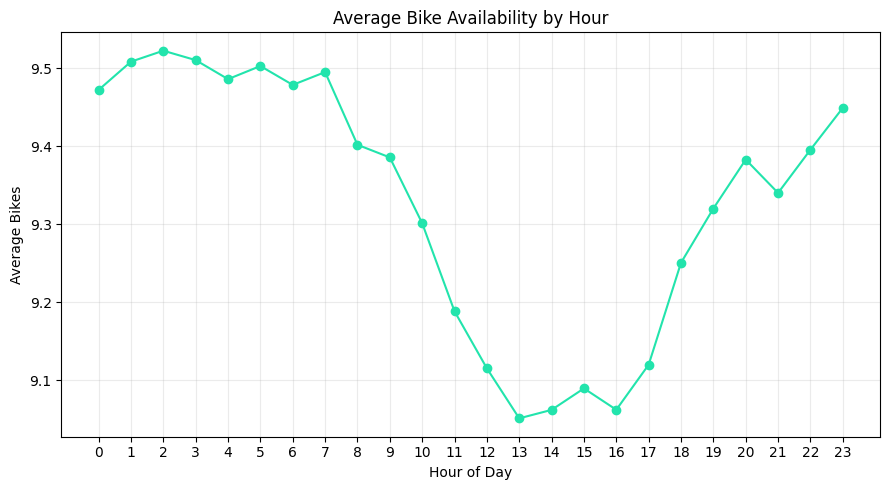

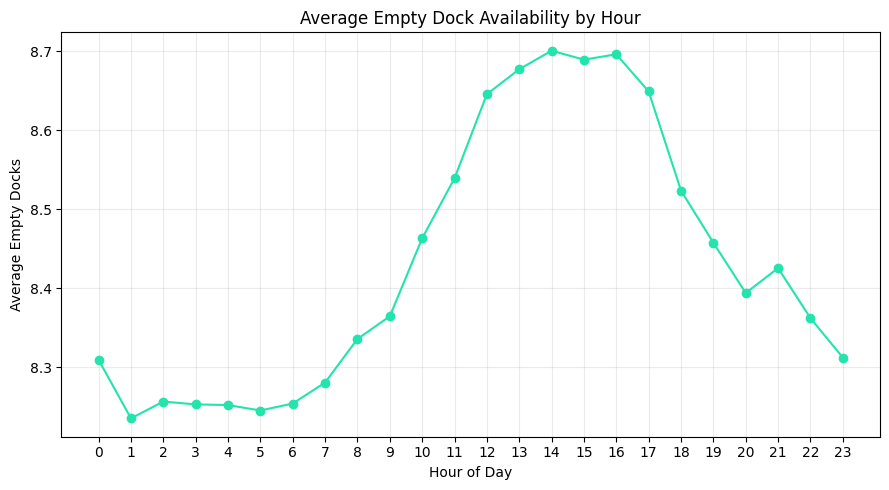

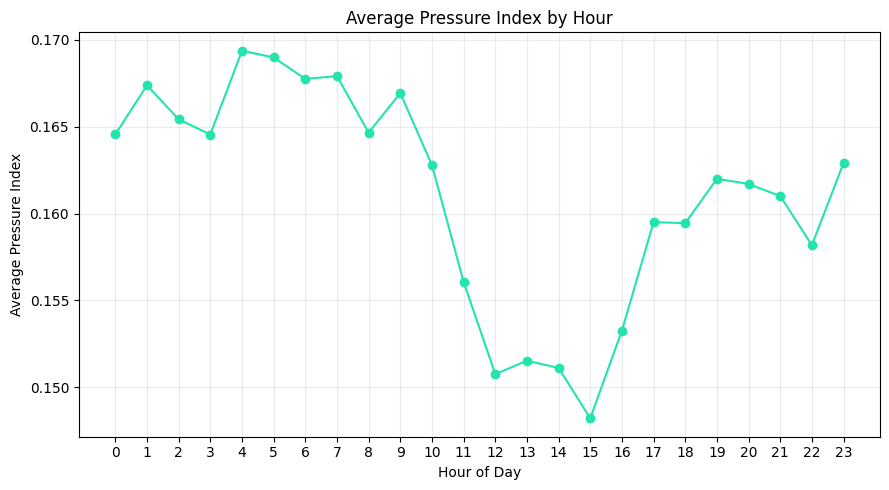

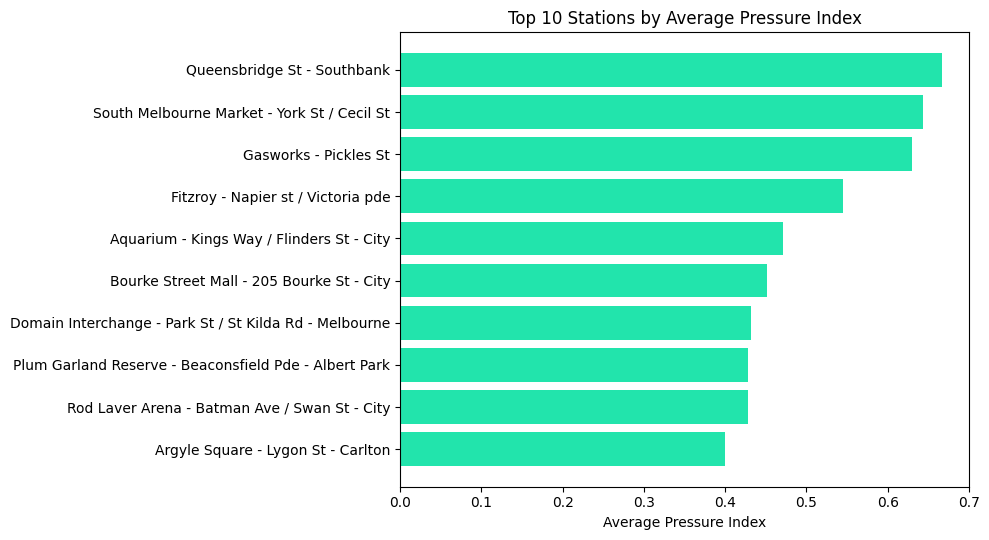

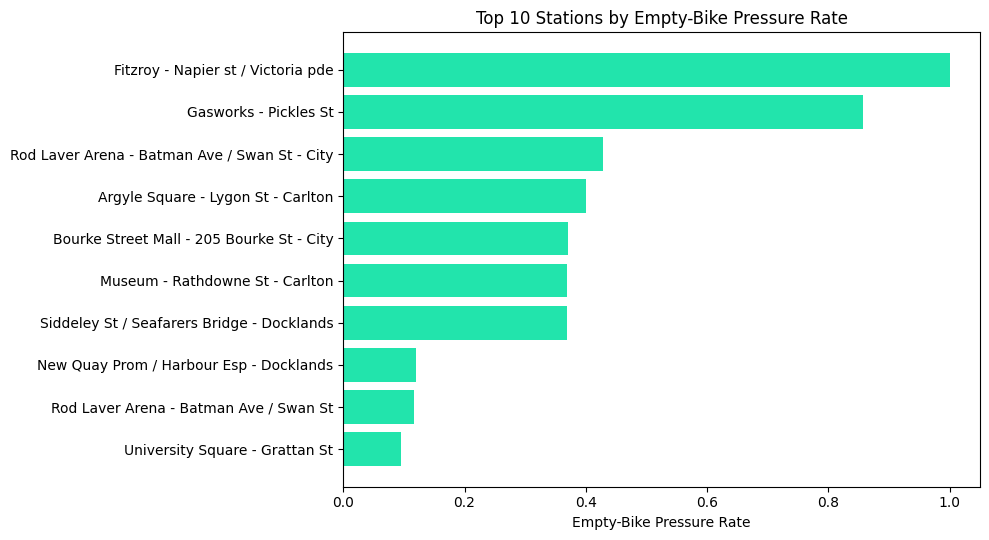

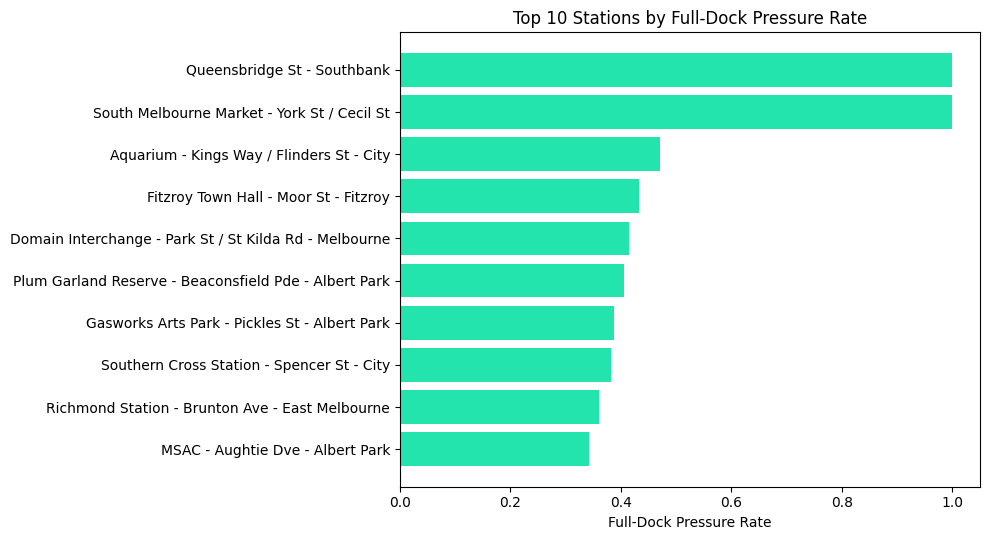

,ID,NAME,avg_pressure_index,empty_bike_pressure_rate,full_dock_pressure_rate,avg_bikes,avg_empty_docks,records
53,28,Queensbridge St - Southbank,0.666667,0.000000,1.000000,14.000000,1.000000,1
93,46,South Melbourne Market - York St / Cecil St,0.642857,0.000000,1.000000,13.000000,1.000000,1
58,30,Gasworks - Pickles St,0.629870,0.857143,0.000000,1.071429,9.928571,14
73,36,Fitzroy - Napier st / Victoria pde,0.545455,1.000000,0.000000,1.000000,10.000000,1
77,38,Aquarium - Kings Way / Flinders St - City,0.470824,0.033874,0.471043,8.135889,2.729624,11897
9,7,Bourke Street Mall - 205 Bourke St - City,0.451849,0.371196,0.108810,4.215805,6.702085,11929
83,41,Domain Interchange - Park St / St Kilda Rd - M...,0.432090,0.012321,0.414718,11.194758,3.665005,11931
22,14,Plum Garland Reserve - Beaconsfield Pde - Albe...,0.428642,0.007708,0.405865,13.351762,4.953472,11287
82,40,Rod Laver Arena - Batman Ave / Swan St - City,0.428268,0.427666,0.008593,5.575249,17.181774,11986
30,18,Argyle Square - Lygon St - Carlton,0.399824,0.400335,0.014154,3.034052,7.910295,11940


In [7]:
# ============================================================
# 6. Use Case 3: Demand pattern and pressure analysis
# ============================================================


# Hourly averages.
hourly_profile = hourly.groupby("hour", as_index=False).agg(
    avg_bikes=(bikes_col, "mean"),
    avg_empty_docks=(empty_col, "mean"),
    avg_pressure_index=("pressure_index", "mean"),
    empty_bike_pressure_rate=("empty_bike_pressure", "mean"),
    full_dock_pressure_rate=("full_dock_pressure", "mean"),
)
hourly_profile.to_csv(TABLE_DIR / "hourly_demand_pressure_profile.csv", index=False)

def line_chart(df, x, y, title, ylabel, out_name):
    plt.figure(figsize=(9, 5))
    plt.plot(df[x], df[y], marker="o", color=PRIMARY_COLOR)
    plt.title(title)
    plt.xlabel("Hour of Day")
    plt.ylabel(ylabel)
    plt.xticks(range(0, 24))
    plt.grid(alpha=0.25)
    save_fig(FIGURE_DIR / out_name)

line_chart(hourly_profile, "hour", "avg_bikes", "Average Bike Availability by Hour", "Average Bikes", "hourly_avg_bikes.png")
line_chart(hourly_profile, "hour", "avg_empty_docks", "Average Empty Dock Availability by Hour", "Average Empty Docks", "hourly_avg_empty_docks.png")
line_chart(hourly_profile, "hour", "avg_pressure_index", "Average Pressure Index by Hour", "Average Pressure Index", "hourly_pressure_index.png")

# Station pressure rankings.
station_group_cols = [station_id_col]
if station_name_col is not None:
    station_group_cols.append(station_name_col)

station_pressure = hourly.groupby(station_group_cols, as_index=False).agg(
    avg_pressure_index=("pressure_index", "mean"),
    empty_bike_pressure_rate=("empty_bike_pressure", "mean"),
    full_dock_pressure_rate=("full_dock_pressure", "mean"),
    avg_bikes=(bikes_col, "mean"),
    avg_empty_docks=(empty_col, "mean"),
    records=("hour_ts", "count"),
).sort_values("avg_pressure_index", ascending=False)

top_pressure = station_pressure.head(10).copy()
top_empty_bike = station_pressure.sort_values("empty_bike_pressure_rate", ascending=False).head(10).copy()
top_full_dock = station_pressure.sort_values("full_dock_pressure_rate", ascending=False).head(10).copy()

top_pressure.to_csv(TABLE_DIR / "top_pressure_stations.csv", index=False)
top_empty_bike.to_csv(TABLE_DIR / "top_empty_bike_pressure_stations.csv", index=False)
top_full_dock.to_csv(TABLE_DIR / "top_full_dock_pressure_stations.csv", index=False)

label_col = station_name_col if station_name_col is not None else station_id_col

def barh_top(df, value_col, title, xlabel, out_name):
    labels = df[label_col].astype(str)
    plt.figure(figsize=(10, 5.5))
    plt.barh(labels, df[value_col], color=PRIMARY_COLOR)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    save_fig(FIGURE_DIR / out_name)

barh_top(top_pressure, "avg_pressure_index", "Top 10 Stations by Average Pressure Index", "Average Pressure Index", "top_pressure_stations.png")
barh_top(top_empty_bike, "empty_bike_pressure_rate", "Top 10 Stations by Empty-Bike Pressure Rate", "Empty-Bike Pressure Rate", "top_empty_bike_pressure_stations.png")
barh_top(top_full_dock, "full_dock_pressure_rate", "Top 10 Stations by Full-Dock Pressure Rate", "Full-Dock Pressure Rate", "top_full_dock_pressure_stations.png")

## Top high-pressure stations
display_head(top_pressure, 10)


<p class="usecase-subsection-header">7. Week 1 reproduction: non-graph multi-horizon baselines</p>

This section validates Use Case 1 and Use Case 2 using non-graph forecasting models. The models predict future bike availability and future empty dock availability for 1-hour, 3-hour, and 6-hour horizons.

The baselines are:

- **Naive persistence:** assumes the future value is the current value.  
- **Station-hour mean:** uses average historical target value for each station and hour.  
- **Linear Regression:** a simple interpretable supervised learning model.  
- **Random Forest:** a non-linear supervised learning model trained on a controlled sample when needed for runtime.


In [8]:
# ============================================================
# 7. Multi-horizon supervised forecasting setup
# ============================================================


model_base = hourly.copy()

# Filter to the final test window if available.
model_base = model_base[model_base["hour_ts"] <= TEST_END].copy()

# Add split column using date-based split.
model_base["split"] = "test"
model_base.loc[model_base["hour_ts"] <= TRAIN_END, "split"] = "train"
model_base.loc[(model_base["hour_ts"] > TRAIN_END) & (model_base["hour_ts"] <= VAL_END), "split"] = "validation"

# Fallback only if date split is impossible for a user's local copy.
split_counts = model_base["split"].value_counts().to_dict()
if any(split_counts.get(s, 0) == 0 for s in ["train", "validation", "test"]):
    
# Date-split fallback notice:** The expected 2016-2017 split did not produce all train/validation/test periods for this local file. The notebook will use a chronological 70/15/15 split so the code remains runnable. If the full expected date range is available, the fixed date split is used automatically.

    unique_ts = np.array(sorted(model_base["hour_ts"].dropna().unique()))
    train_cut = unique_ts[int(len(unique_ts) * 0.70)]
    val_cut = unique_ts[int(len(unique_ts) * 0.85)]
    model_base["split"] = "test"
    model_base.loc[model_base["hour_ts"] <= train_cut, "split"] = "train"
    model_base.loc[(model_base["hour_ts"] > train_cut) & (model_base["hour_ts"] <= val_cut), "split"] = "validation"

# Create exact future targets by merging on station and future timestamp.
for h in HORIZONS:
    future = model_base[[station_id_col, "hour_ts", bikes_col, empty_col]].copy()
    future = future.rename(columns={
        "hour_ts": "future_hour_ts",
        bikes_col: f"target_bikes_{h}h",
        empty_col: f"target_empty_docks_{h}h",
    })
    model_base[f"future_hour_ts_{h}h"] = model_base["hour_ts"] + pd.Timedelta(hours=h)
    model_base = model_base.merge(
        future,
        left_on=[station_id_col, f"future_hour_ts_{h}h"],
        right_on=[station_id_col, "future_hour_ts"],
        how="left"
    ).drop(columns=["future_hour_ts"])

split_summary = model_base.groupby("split", as_index=False).agg(
    rows=("hour_ts", "count"),
    stations=(station_id_col, "nunique"),
    date_min=("hour_ts", "min"),
    date_max=("hour_ts", "max"),
)
split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)
display_head(split_summary, 10)

# Keep a modelling-ready table for each horizon.
horizon_frames = {}
for h in HORIZONS:
    dfh = model_base.dropna(subset=[f"target_bikes_{h}h", f"target_empty_docks_{h}h"]).copy()
    horizon_frames[h] = dfh
    print(f"Horizon {h}h modelling shape:", dfh.shape)


,split,rows,stations,date_min,date_max
0,test,113730,50,2017-04-01 00:00:00,2017-09-29 23:00:00
1,train,375284,52,2015-04-22 12:00:00,2016-12-31 23:00:00
2,validation,57702,50,2017-01-01 00:00:00,2017-03-31 23:00:00


Horizon 1h modelling shape: (297123, 58)
Horizon 3h modelling shape: (297259, 58)
Horizon 6h modelling shape: (298703, 58)


<p class="usecase-subsection-header">8. Station graph construction</p>

This section introduces the graph-learning component. Each bike-share station is represented as a graph node. Edges connect geographically nearby stations using a distance-based k-nearest-neighbour approach. This captures the spatial relationship between stations and supports graph-aware forecasting.


Non-graph feature count: 43


,horizon_h,target,model,MAE,RMSE,R2
0,1,bikes,naive_persistence,0.378223,1.026548,0.966505
1,1,empty_docks,naive_persistence,0.376119,1.023805,0.969153
2,3,bikes,naive_persistence,0.820337,1.688212,0.908928
3,3,empty_docks,naive_persistence,0.814368,1.679334,0.917300
4,6,bikes,naive_persistence,1.286952,2.284191,0.834149
5,6,empty_docks,naive_persistence,1.277446,2.272162,0.846937


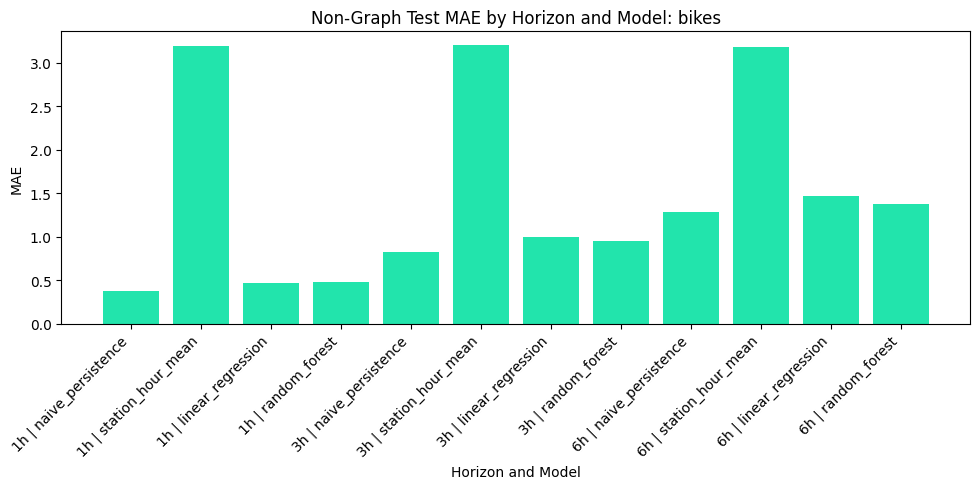

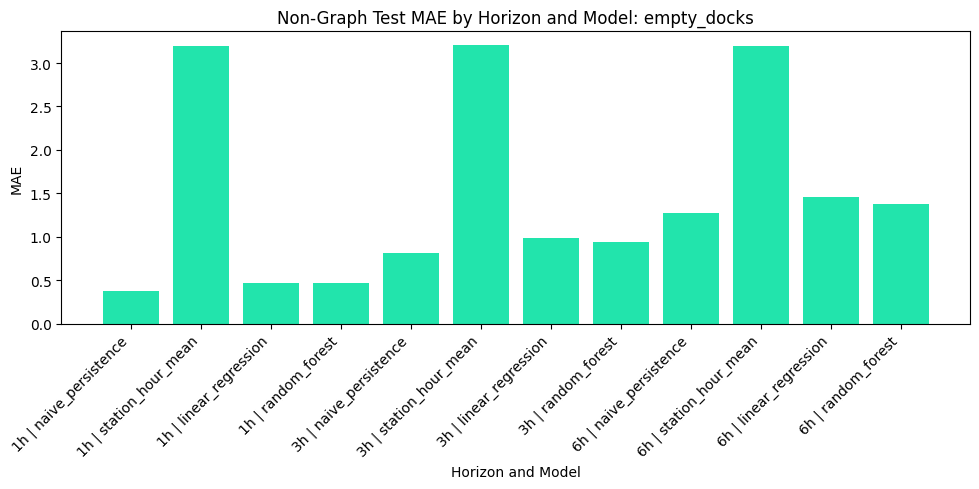

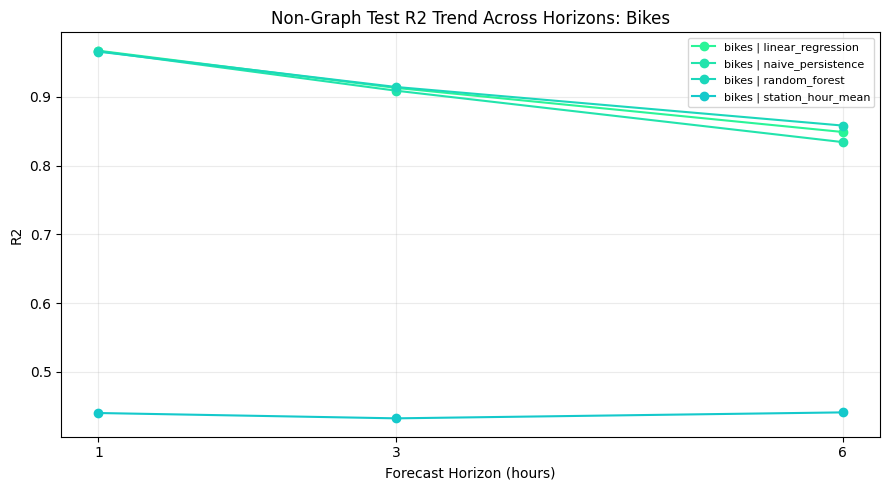

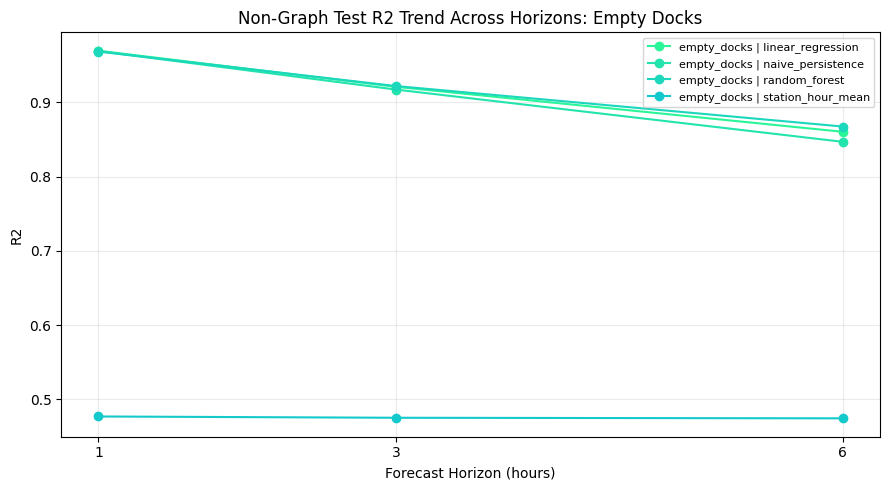

In [9]:
# ============================================================
# 8. Non-graph baseline models for 1h, 3h, and 6h
# ============================================================


base_feature_candidates = [
    bikes_col, empty_col, lat_col, lon_col,
    "hour", "day_of_week", "month", "is_weekend",
    "total_docks_est", "bike_ratio", "empty_dock_ratio",
    "empty_bike_pressure", "full_dock_pressure", "pressure_index",
    "station_enc",
] + lag_roll_cols

base_features = [c for c in base_feature_candidates if c in model_base.columns]
print("Non-graph feature count:", len(base_features))


def fit_station_hour_mean(train, y_col):
    tbl = train.groupby([station_id_col, "hour"], as_index=False)[y_col].mean().rename(columns={y_col: "pred"})
    global_mean = float(train[y_col].mean())
    return tbl, global_mean


def pred_station_hour_mean(df, tbl, global_mean):
    tmp = df[[station_id_col, "hour"]].merge(tbl, on=[station_id_col, "hour"], how="left")
    return tmp["pred"].fillna(global_mean).to_numpy()


def make_lr_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def make_rf_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_depth=18,
            min_samples_leaf=2,
        )),
    ])

baseline_rows = []

for h in HORIZONS:
    dfh = horizon_frames[h].copy()
    train = dfh[dfh["split"] == "train"].copy()
    val = dfh[dfh["split"] == "validation"].copy()
    test = dfh[dfh["split"] == "test"].copy()

    if len(train) == 0 or len(val) == 0 or len(test) == 0:
        print(f"Skipping horizon {h}h because one or more splits are empty.")
        continue

    for target_col, target_clean, current_col in [
        (f"target_bikes_{h}h", "bikes", bikes_col),
        (f"target_empty_docks_{h}h", "empty_docks", empty_col),
    ]:
        # Naive persistence.
        for split_name, split_df in [("validation", val), ("test", test)]:
            pred = split_df[current_col].to_numpy()
            m = regression_metrics(split_df[target_col], pred)
            baseline_rows.append({"horizon_h": h, "target": target_clean, "model": "naive_persistence", "split": split_name, **m})

        # Station-hour mean.
        tbl, gmean = fit_station_hour_mean(train, target_col)
        for split_name, split_df in [("validation", val), ("test", test)]:
            pred = pred_station_hour_mean(split_df, tbl, gmean)
            m = regression_metrics(split_df[target_col], pred)
            baseline_rows.append({"horizon_h": h, "target": target_clean, "model": "station_hour_mean", "split": split_name, **m})

        # Linear regression.
        lr = make_lr_pipeline()
        lr.fit(train[base_features], train[target_col])
        for split_name, split_df in [("validation", val), ("test", test)]:
            pred = lr.predict(split_df[base_features])
            m = regression_metrics(split_df[target_col], pred)
            baseline_rows.append({"horizon_h": h, "target": target_clean, "model": "linear_regression", "split": split_name, **m})

        # Random forest with controlled training sample.
        if RUN_RANDOM_FOREST:
            rf_train = sample_for_rf(train, MAX_RF_TRAIN_ROWS)
            rf = make_rf_pipeline()
            rf.fit(rf_train[base_features], rf_train[target_col])
            for split_name, split_df in [("validation", val), ("test", test)]:
                pred = rf.predict(split_df[base_features])
                m = regression_metrics(split_df[target_col], pred)
                baseline_rows.append({"horizon_h": h, "target": target_clean, "model": "random_forest", "split": split_name, **m})

non_graph_results = pd.DataFrame(baseline_rows)
non_graph_results.to_csv(TABLE_DIR / "non_graph_multi_horizon_results.csv", index=False)

leaderboard = (
    non_graph_results[non_graph_results["split"] == "test"]
    .sort_values(["horizon_h", "target", "MAE"])
    .groupby(["horizon_h", "target"], as_index=False)
    .first()[["horizon_h", "target", "model", "MAE", "RMSE", "R2"]]
)
leaderboard.to_csv(TABLE_DIR / "non_graph_leaderboard.csv", index=False)

# Non-graph benchmark leaderboard: best test model for each target and horizon
display_head(leaderboard, 20)

# Visual: Test MAE by model/horizon/target.
test_baseline = non_graph_results[non_graph_results["split"] == "test"].copy()
for target in sorted(test_baseline["target"].unique()):
    plt.figure(figsize=(10, 5))
    sub = test_baseline[test_baseline["target"] == target].copy()
    labels = sub["horizon_h"].astype(str) + "h | " + sub["model"].astype(str)
    plt.bar(labels, sub["MAE"], color=PRIMARY_COLOR)
    plt.title(f"Non-Graph Test MAE by Horizon and Model: {target}")
    plt.xlabel("Horizon and Model")
    plt.ylabel("MAE")
    plt.xticks(rotation=45, ha="right")
    save_fig(FIGURE_DIR / f"non_graph_test_mae_by_horizon_{target}.png")

# Combined R2 trend chart.
plt.figure(figsize=(9, 5))
for color_idx, model_name in enumerate(sorted(test_baseline["model"].unique())):
    trend = test_baseline[(test_baseline["target"] == "bikes") & (test_baseline["model"] == model_name)].sort_values("horizon_h")
    if len(trend):
        plt.plot(trend["horizon_h"], trend["R2"], marker="o", color=COMPANY_STYLE_COLORS[color_idx % len(COMPANY_STYLE_COLORS)], label=f"bikes | {model_name}")
plt.title("Non-Graph Test R2 Trend Across Horizons: Bikes")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("R2")
plt.xticks(HORIZONS)
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
save_fig(FIGURE_DIR / "non_graph_test_r2_by_horizon_bikes.png")

plt.figure(figsize=(9, 5))
for color_idx, model_name in enumerate(sorted(test_baseline["model"].unique())):
    trend = test_baseline[(test_baseline["target"] == "empty_docks") & (test_baseline["model"] == model_name)].sort_values("horizon_h")
    if len(trend):
        plt.plot(trend["horizon_h"], trend["R2"], marker="o", color=COMPANY_STYLE_COLORS[color_idx % len(COMPANY_STYLE_COLORS)], label=f"empty_docks | {model_name}")
plt.title("Non-Graph Test R2 Trend Across Horizons: Empty Docks")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("R2")
plt.xticks(HORIZONS)
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
save_fig(FIGURE_DIR / "non_graph_test_r2_by_horizon_empty_docks.png")


<p class="usecase-subsection-header">9. Graph feature engineering</p>

Graph-derived features allow each station prediction to use information from neighbouring stations. For example, if nearby stations also have few bikes or few empty docks, the target station may be at greater operational risk.

This is the graph-aware part of the final forecasting pipeline.


Graph statistics:
- nodes: 52
- edges: 172
- avg_degree: 6.615384615384615
- min_degree: 5
- max_degree: 10
- k_nearest_neighbors: 5


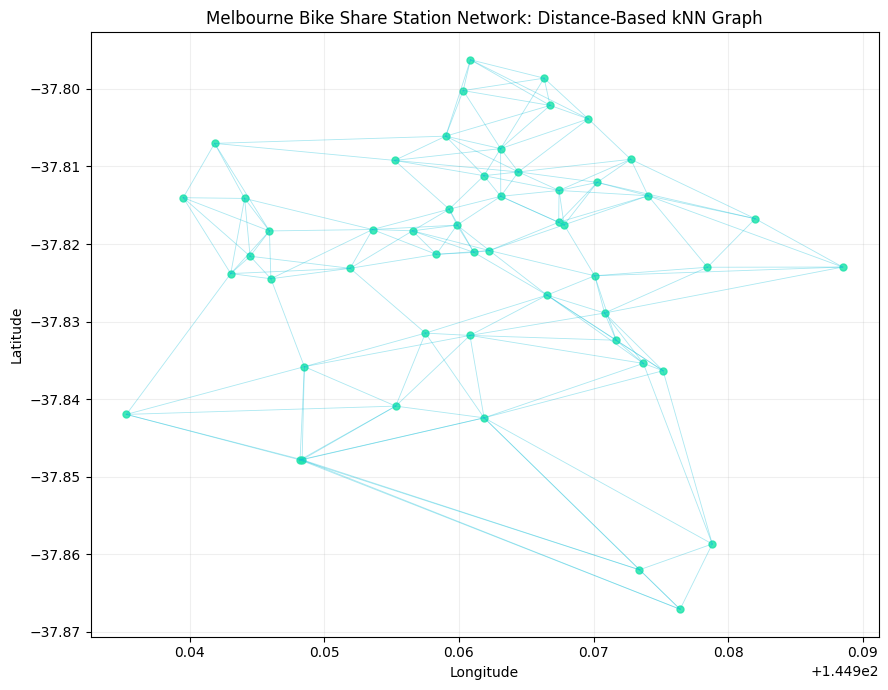

In [10]:
# ============================================================
# 9. Station graph construction
# ============================================================


station_cols = [station_id_col, lat_col, lon_col]
if station_name_col is not None:
    station_cols.append(station_name_col)

stations = hourly[station_cols].drop_duplicates(subset=[station_id_col]).reset_index(drop=True)
stations[lat_col] = pd.to_numeric(stations[lat_col], errors="coerce")
stations[lon_col] = pd.to_numeric(stations[lon_col], errors="coerce")
stations = stations.dropna(subset=[lat_col, lon_col]).reset_index(drop=True)

coords = stations[[lat_col, lon_col]].to_numpy(dtype=float)
station_ids = stations[station_id_col].to_numpy()


def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

n = len(stations)
D = np.zeros((n, n), dtype=float)
for i in range(n):
    D[i, :] = haversine_vec(coords[i, 0], coords[i, 1], coords[:, 0], coords[:, 1])

k = 5 if n >= 6 else max(1, n - 1)
edges = set()
for i in range(n):
    nearest = np.argsort(D[i])[1:k + 1]
    for j in nearest:
        a, b = station_ids[i], station_ids[j]
        if a != b:
            edges.add(tuple(sorted((a, b))))

edges_df = pd.DataFrame(list(edges), columns=["station_a", "station_b"])
id_to_idx = {sid: idx for idx, sid in enumerate(station_ids)}
edges_df["distance_km"] = edges_df.apply(lambda r: D[id_to_idx[r["station_a"]], id_to_idx[r["station_b"]]], axis=1)
edges_df = edges_df.sort_values("distance_km").reset_index(drop=True)
edges_df.to_csv(TABLE_DIR / "station_graph_edges.csv", index=False)

G = nx.Graph()
G.add_nodes_from(station_ids)
for _, r in edges_df.iterrows():
    G.add_edge(r["station_a"], r["station_b"], distance_km=float(r["distance_km"]))

degrees = np.array([d for _, d in G.degree()])
graph_stats = {
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
    "avg_degree": float(degrees.mean()) if len(degrees) else 0.0,
    "min_degree": int(degrees.min()) if len(degrees) else 0,
    "max_degree": int(degrees.max()) if len(degrees) else 0,
    "k_nearest_neighbors": int(k),
}
with open(TABLE_DIR / "station_graph_stats.json", "w", encoding="utf-8") as f:
    json.dump(graph_stats, f, indent=2)

print("Graph statistics:")
for key, value in graph_stats.items():
    print(f"- {key}: {value}")

# Graph map.
coord_map = stations.set_index(station_id_col)[[lon_col, lat_col]].to_dict("index")
plt.figure(figsize=(9, 7))
for _, r in edges_df.iterrows():
    a, b = r["station_a"], r["station_b"]
    xa, ya = coord_map[a][lon_col], coord_map[a][lat_col]
    xb, yb = coord_map[b][lon_col], coord_map[b][lat_col]
    plt.plot([xa, xb], [ya, yb], linewidth=0.6, alpha=0.35, color=ACCENT_COLOR)
plt.scatter(stations[lon_col], stations[lat_col], s=25, alpha=0.85, color=PRIMARY_COLOR)
plt.title("Melbourne Bike Share Station Network: Distance-Based kNN Graph")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.20)
save_fig(FIGURE_DIR / "station_graph_map.png")


<p class="usecase-subsection-header">10. Final 6-hour graph-aware forecasting</p>

The 6-hour horizon is used as the final operational benchmark because it gives operators enough time to plan redistribution before a station becomes empty or full.

This section compares two feature sets:

- **Non-graph features:** station state, time features, pressure features, and lag/rolling features.  
- **Graph features:** all non-graph features plus neighbouring station conditions.

The comparison demonstrates whether spatial graph-derived features add predictive value.


In [11]:
# ============================================================
# 10. Graph feature engineering
# ============================================================


long_edges = pd.concat([
    edges_df[["station_a", "station_b"]].rename(columns={"station_a": "station_id", "station_b": "neighbor_id"}),
    edges_df[["station_b", "station_a"]].rename(columns={"station_b": "station_id", "station_a": "neighbor_id"}),
], ignore_index=True)

base_neighbor_values = hourly[[
    station_id_col, "hour_ts", bikes_col, empty_col,
    "pressure_index", "empty_bike_pressure", "full_dock_pressure"
]].rename(columns={station_id_col: "station_id"})

station_time_keys = base_neighbor_values[["station_id", "hour_ts"]].drop_duplicates()
neighbor_map = station_time_keys.merge(long_edges, on="station_id", how="left")

neighbor_values = neighbor_map.merge(
    base_neighbor_values.rename(columns={
        "station_id": "neighbor_id",
        bikes_col: "neighbor_bikes",
        empty_col: "neighbor_empty_docks",
        "pressure_index": "neighbor_pressure",
        "empty_bike_pressure": "neighbor_empty_bike_pressure",
        "full_dock_pressure": "neighbor_full_dock_pressure",
    }),
    on=["neighbor_id", "hour_ts"],
    how="left"
)

graph_feats = neighbor_values.groupby(["station_id", "hour_ts"], as_index=False).agg(
    neighbor_avg_bikes=("neighbor_bikes", "mean"),
    neighbor_avg_empty_docks=("neighbor_empty_docks", "mean"),
    neighbor_pressure_mean=("neighbor_pressure", "mean"),
    neighbor_bikes_std=("neighbor_bikes", "std"),
    neighbor_empty_std=("neighbor_empty_docks", "std"),
    neighbor_empty_bike_pressure_mean=("neighbor_empty_bike_pressure", "mean"),
    neighbor_full_dock_pressure_mean=("neighbor_full_dock_pressure", "mean"),
)

graph_feature_cols = [
    "neighbor_avg_bikes",
    "neighbor_avg_empty_docks",
    "neighbor_pressure_mean",
    "neighbor_bikes_std",
    "neighbor_empty_std",
    "neighbor_empty_bike_pressure_mean",
    "neighbor_full_dock_pressure_mean",
]

for c in graph_feature_cols:
    graph_feats[c] = graph_feats[c].fillna(graph_feats[c].median())

model_graph = model_base.merge(
    graph_feats,
    left_on=[station_id_col, "hour_ts"],
    right_on=["station_id", "hour_ts"],
    how="left"
).drop(columns=["station_id"])

for c in graph_feature_cols:
    model_graph[c] = model_graph[c].fillna(model_graph[c].median())

model_graph.to_csv(TABLE_DIR / "graph_feature_dataset.csv", index=False)
print("Graph-feature modelling table shape:", model_graph.shape)
print("Graph feature columns:", graph_feature_cols)


Graph-feature modelling table shape: (546716, 65)
Graph feature columns: ['neighbor_avg_bikes', 'neighbor_avg_empty_docks', 'neighbor_pressure_mean', 'neighbor_bikes_std', 'neighbor_empty_std', 'neighbor_empty_bike_pressure_mean', 'neighbor_full_dock_pressure_mean']


<p class="usecase-subsection-header">11. Graph improvement analysis</p>

This section calculates the percentage MAE improvement from adding graph-neighbour features. This directly shows whether the graph-aware modelling stage contributed additional predictive value compared with station-only features.


6-hour modelling shapes:
Train: (205320, 65) Validation: (31370, 65) Test: (62013, 65)
Non-graph feature count: 43
Graph feature count: 50


,Target,Model,Feature Set,Split,MAE,RMSE,R2
0,Bikes 6h,Random Forest,Non-graph,test,1.376290,2.111965,0.858216
1,Bikes 6h,Random Forest,Graph features,test,1.385864,2.115525,0.857738
2,Bikes 6h,Linear Regression,Graph features,test,1.463677,2.179721,0.848973
3,Bikes 6h,Linear Regression,Non-graph,test,1.464023,2.180387,0.848880
4,Bikes 6h,Random Forest,Graph features,validation,1.821417,2.700100,0.815989
5,Bikes 6h,Random Forest,Non-graph,validation,1.823910,2.702458,0.815668
6,Bikes 6h,Linear Regression,Graph features,validation,1.898634,2.786496,0.804025
7,Bikes 6h,Linear Regression,Non-graph,validation,1.899002,2.787060,0.803946
8,Empty Docks 6h,Random Forest,Non-graph,test,1.371955,2.113799,0.867530
9,Empty Docks 6h,Random Forest,Graph features,test,1.378276,2.117230,0.867099


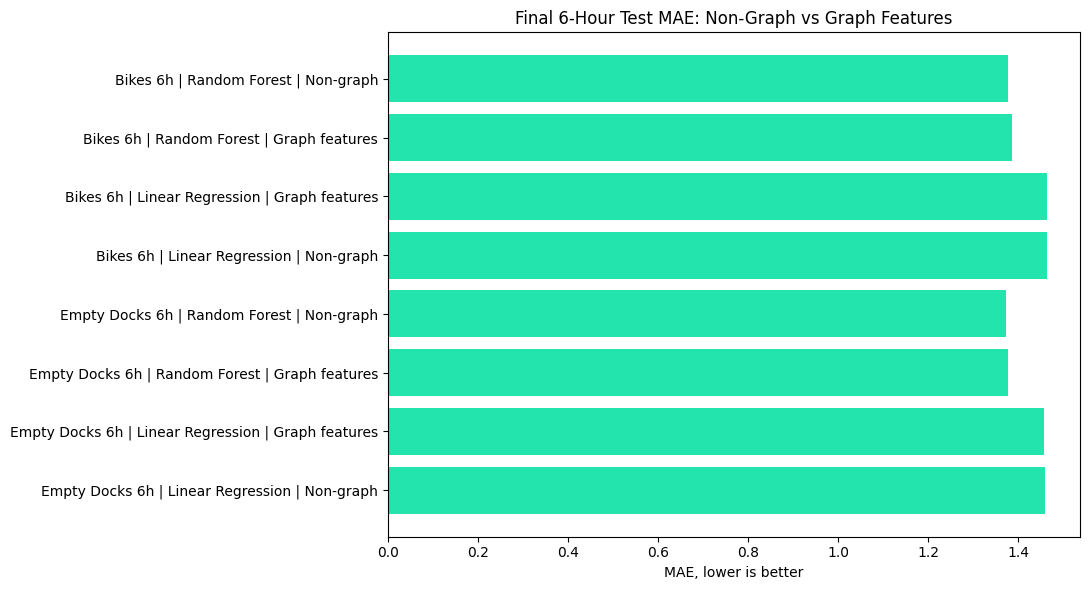

In [12]:
# ============================================================
# 11. Final 6-hour graph-aware forecasting comparison
# ============================================================


h = 6
df6 = model_graph.dropna(subset=[f"target_bikes_{h}h", f"target_empty_docks_{h}h"]).copy()
train6 = df6[df6["split"] == "train"].copy()
val6 = df6[df6["split"] == "validation"].copy()
test6 = df6[df6["split"] == "test"].copy()

non_graph_features = [c for c in base_features if c in df6.columns]
graph_features = non_graph_features + [c for c in graph_feature_cols if c in df6.columns]

print("6-hour modelling shapes:")
print("Train:", train6.shape, "Validation:", val6.shape, "Test:", test6.shape)
print("Non-graph feature count:", len(non_graph_features))
print("Graph feature count:", len(graph_features))

final_rows = []
model_store = {}

for target_col, target_label in [("target_bikes_6h", "Bikes 6h"), ("target_empty_docks_6h", "Empty Docks 6h")]:
    for feature_set_name, feature_cols in [("Non-graph", non_graph_features), ("Graph features", graph_features)]:
        # Linear Regression
        lr = make_lr_pipeline()
        lr.fit(train6[feature_cols], train6[target_col])
        model_store[(target_label, "Linear Regression", feature_set_name)] = (lr, feature_cols)
        for split_name, split_df in [("validation", val6), ("test", test6)]:
            pred = lr.predict(split_df[feature_cols])
            m = regression_metrics(split_df[target_col], pred)
            final_rows.append({"Target": target_label, "Model": "Linear Regression", "Feature Set": feature_set_name, "Split": split_name, **m})

        # Random Forest
        if RUN_RANDOM_FOREST:
            rf_train = sample_for_rf(train6, MAX_RF_TRAIN_ROWS)
            rf = make_rf_pipeline()
            rf.fit(rf_train[feature_cols], rf_train[target_col])
            model_store[(target_label, "Random Forest", feature_set_name)] = (rf, feature_cols)
            for split_name, split_df in [("validation", val6), ("test", test6)]:
                pred = rf.predict(split_df[feature_cols])
                m = regression_metrics(split_df[target_col], pred)
                final_rows.append({"Target": target_label, "Model": "Random Forest", "Feature Set": feature_set_name, "Split": split_name, **m})

final_comparison = pd.DataFrame(final_rows).sort_values(["Target", "Split", "MAE"]).reset_index(drop=True)
final_comparison.to_csv(TABLE_DIR / "final_graph_model_comparison.csv", index=False)

# Final graph-aware model comparison
display_head(final_comparison, 20)

# Plot test MAE comparison.
test_final = final_comparison[final_comparison["Split"] == "test"].copy()
test_final["label"] = test_final["Target"] + " | " + test_final["Model"] + " | " + test_final["Feature Set"]
plt.figure(figsize=(11, 6))
plt.barh(test_final["label"], test_final["MAE"], color=PRIMARY_COLOR)
plt.gca().invert_yaxis()
plt.title("Final 6-Hour Test MAE: Non-Graph vs Graph Features")
plt.xlabel("MAE, lower is better")
save_fig(FIGURE_DIR / "final_graph_model_comparison_mae.png")


<p class="usecase-subsection-header">12. Final model selection</p>

The final model is selected separately for bike prediction and empty dock prediction. Selection uses validation MAE among graph-feature models, then the selected model type is refit on train plus validation data and evaluated on the held-out test set.

This avoids choosing the model directly from the test set while still reporting final test performance.


,Target,Model,Non-Graph MAE,Graph MAE,MAE Improvement %
3,Empty Docks 6h,Linear Regression,1.458684,1.458276,0.027967
1,Bikes 6h,Linear Regression,1.464023,1.463677,0.023636
2,Empty Docks 6h,Random Forest,1.371955,1.378276,-0.460750
0,Bikes 6h,Random Forest,1.376290,1.385864,-0.695663


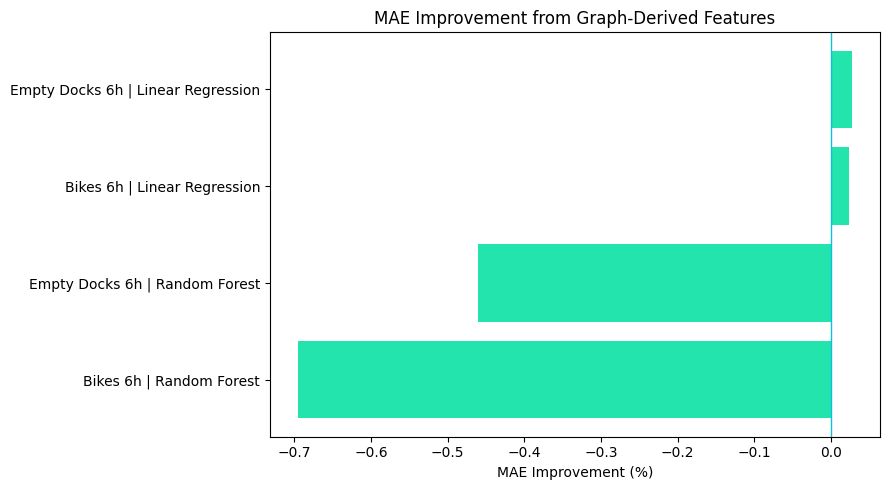

In [13]:
# ============================================================
# 12. Graph improvement analysis
# ============================================================


improvement_rows = []
for target_label in test_final["Target"].unique():
    for model_name in test_final["Model"].unique():
        sub = test_final[(test_final["Target"] == target_label) & (test_final["Model"] == model_name)]
        if {"Non-graph", "Graph features"}.issubset(set(sub["Feature Set"])):
            non_graph_mae = float(sub[sub["Feature Set"] == "Non-graph"]["MAE"].iloc[0])
            graph_mae = float(sub[sub["Feature Set"] == "Graph features"]["MAE"].iloc[0])
            improvement = ((non_graph_mae - graph_mae) / non_graph_mae) * 100 if non_graph_mae != 0 else np.nan
            improvement_rows.append({
                "Target": target_label,
                "Model": model_name,
                "Non-Graph MAE": non_graph_mae,
                "Graph MAE": graph_mae,
                "MAE Improvement %": improvement,
            })

graph_improvement = pd.DataFrame(improvement_rows).sort_values("MAE Improvement %", ascending=False)
graph_improvement.to_csv(TABLE_DIR / "graph_improvement_summary.csv", index=False)
display_head(graph_improvement, 20)

plt.figure(figsize=(9, 5))
if len(graph_improvement):
    labels = graph_improvement["Target"] + " | " + graph_improvement["Model"]
    plt.barh(labels, graph_improvement["MAE Improvement %"], color=PRIMARY_COLOR)
    plt.axvline(0, linewidth=1, color=ACCENT_COLOR)
    plt.title("MAE Improvement from Graph-Derived Features")
    plt.xlabel("MAE Improvement (%)")
    plt.gca().invert_yaxis()
    save_fig(FIGURE_DIR / "graph_improvement_percentage.png")
else:
    print("No graph improvement rows were available to plot.")


<p class="usecase-subsection-header">13. Actual vs predicted diagnostics</p>

These plots compare actual and predicted 6-hour values on the test set. Points close to the diagonal line indicate stronger predictive accuracy. Large deviations indicate cases where station behaviour is harder to forecast.


In [14]:
# ============================================================
# 13. Final model selection and test predictions
# ============================================================


trainval6 = pd.concat([train6, val6], axis=0).reset_index(drop=True)
final_prediction_df = test6[[station_id_col, "hour_ts", "hour", "total_docks_est"]].copy()
if station_name_col is not None and station_name_col in test6.columns:
    final_prediction_df[station_name_col] = test6[station_name_col].values

selected_models = {}
selected_summary_rows = []

for target_col, target_label, pred_col in [
    ("target_bikes_6h", "Bikes 6h", "pred_bikes_6h"),
    ("target_empty_docks_6h", "Empty Docks 6h", "pred_empty_docks_6h"),
]:
    val_candidates = final_comparison[
        (final_comparison["Target"] == target_label) &
        (final_comparison["Feature Set"] == "Graph features") &
        (final_comparison["Split"] == "validation")
    ].sort_values("MAE")

    if len(val_candidates) == 0:
        raise ValueError(f"No validation candidates found for {target_label}.")

    selected_model_name = val_candidates.iloc[0]["Model"]
    if selected_model_name == "Linear Regression":
        final_model = make_lr_pipeline()
    else:
        final_model = make_rf_pipeline()
        trainval_fit = sample_for_rf(trainval6, MAX_RF_TRAIN_ROWS)
        final_model.fit(trainval_fit[graph_features], trainval_fit[target_col])
        pred_test = final_model.predict(test6[graph_features])
        m = regression_metrics(test6[target_col], pred_test)
        final_prediction_df[pred_col] = pred_test
        final_prediction_df[f"actual_{pred_col.replace('pred_', '')}"] = test6[target_col].values
        selected_models[target_label] = (selected_model_name, final_model)
        selected_summary_rows.append({"Target": target_label, "Selected Model": selected_model_name, **m})
        continue

    final_model.fit(trainval6[graph_features], trainval6[target_col])
    pred_test = final_model.predict(test6[graph_features])
    m = regression_metrics(test6[target_col], pred_test)
    final_prediction_df[pred_col] = pred_test
    final_prediction_df[f"actual_{pred_col.replace('pred_', '')}"] = test6[target_col].values
    selected_models[target_label] = (selected_model_name, final_model)
    selected_summary_rows.append({"Target": target_label, "Selected Model": selected_model_name, **m})

selected_summary = pd.DataFrame(selected_summary_rows)
selected_summary.to_csv(TABLE_DIR / "final_selected_model_summary.csv", index=False)
final_prediction_df.to_csv(TABLE_DIR / "final_test_predictions.csv", index=False)

# Final selected model summary
display_head(selected_summary, 10)


,Target,Selected Model,MAE,RMSE,R2
0,Bikes 6h,Random Forest,1.376982,2.111666,0.858256
1,Empty Docks 6h,Random Forest,1.380072,2.114649,0.867423


<p class="usecase-subsection-header">14. Error analysis by station and hour</p>

Overall MAE, RMSE, and R² are useful, but operational planning also requires knowing where forecasting is difficult. This section identifies stations and hours with higher prediction errors.


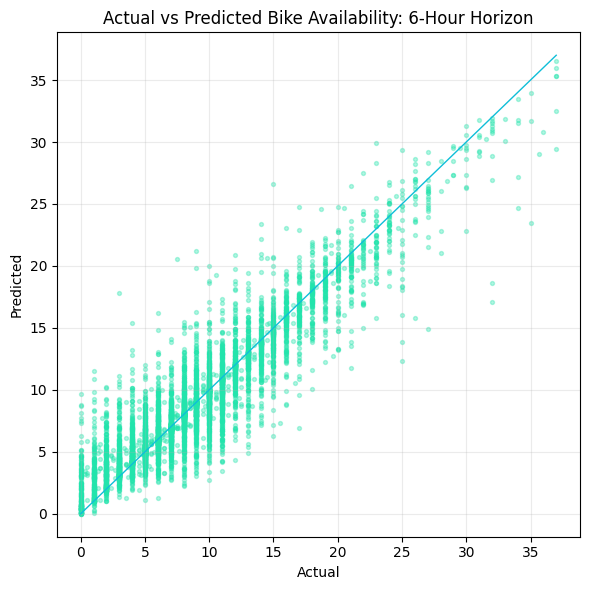

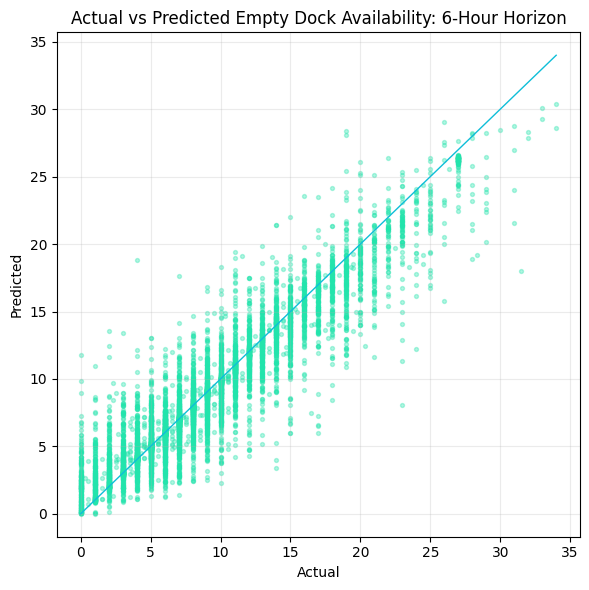

In [15]:
# ============================================================
# 14. Actual vs predicted diagnostics
# ============================================================


plot_sample = final_prediction_df.sample(n=min(MAX_PLOT_POINTS, len(final_prediction_df)), random_state=RANDOM_STATE)

def actual_vs_pred_plot(df, actual_col, pred_col, title, out_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(df[actual_col], df[pred_col], s=8, alpha=0.35, color=PRIMARY_COLOR)
    lo = min(df[actual_col].min(), df[pred_col].min())
    hi = max(df[actual_col].max(), df[pred_col].max())
    plt.plot([lo, hi], [lo, hi], linewidth=1, color=ACCENT_COLOR)
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(alpha=0.25)
    save_fig(FIGURE_DIR / out_name)

actual_vs_pred_plot(
    plot_sample,
    "actual_bikes_6h",
    "pred_bikes_6h",
    "Actual vs Predicted Bike Availability: 6-Hour Horizon",
    "actual_vs_predicted_bikes_6h.png",
)
actual_vs_pred_plot(
    plot_sample,
    "actual_empty_docks_6h",
    "pred_empty_docks_6h",
    "Actual vs Predicted Empty Dock Availability: 6-Hour Horizon",
    "actual_vs_predicted_empty_docks_6h.png",
)


<p class="usecase-subsection-header">15. Operational risk prioritisation</p>

This section converts model predictions into decision-support outputs. A station is flagged as an **empty-bike risk** when predicted bikes are very low, and a **full-dock risk** when predicted empty docks are very low.

This directly supports redistribution planning because operators can focus on stations likely to run out of bikes or return capacity within the next six hours.


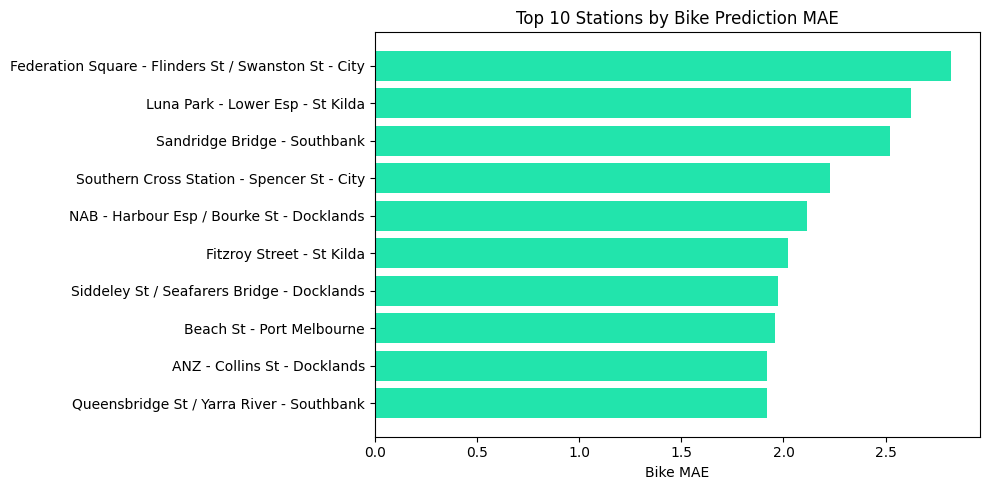

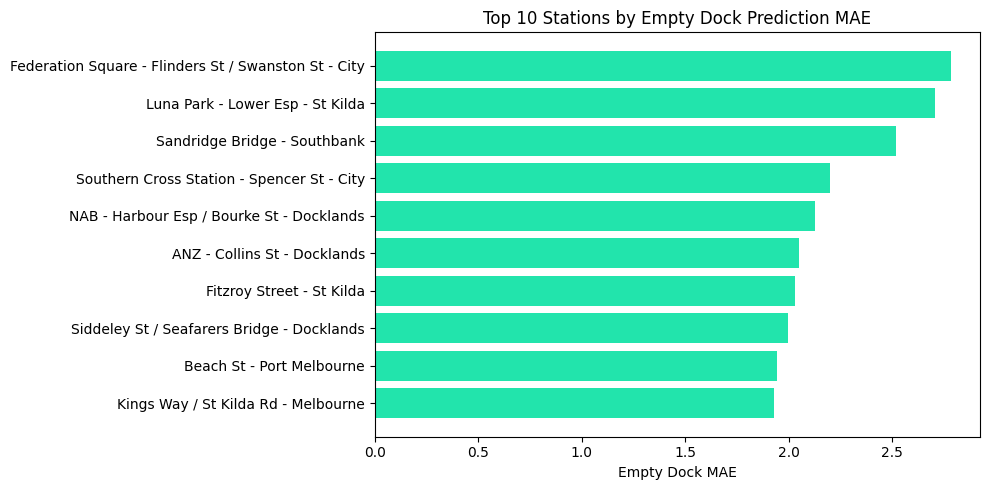

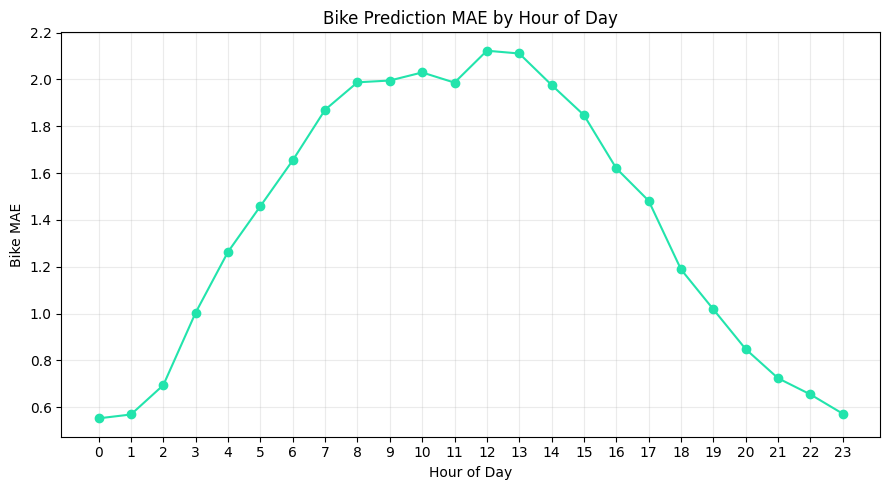

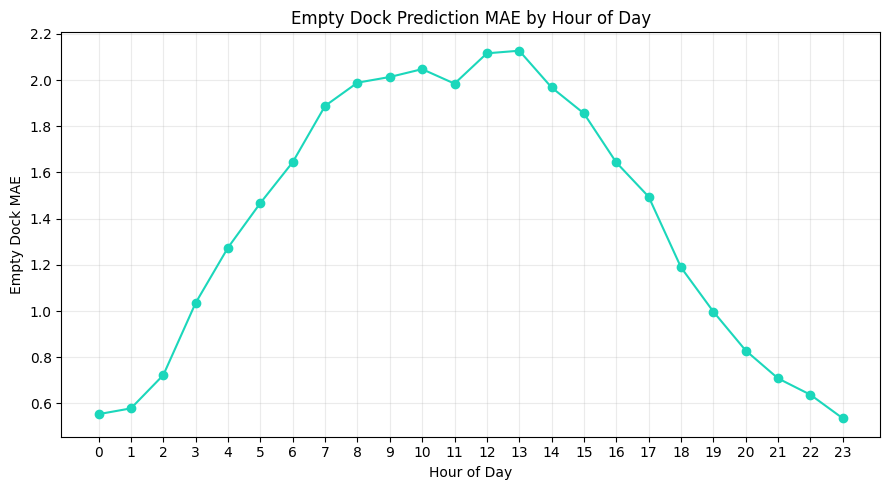

In [16]:
# ============================================================
# 15. Error analysis by station and hour
# ============================================================


final_prediction_df["bike_abs_error"] = (final_prediction_df["actual_bikes_6h"] - final_prediction_df["pred_bikes_6h"]).abs()
final_prediction_df["empty_dock_abs_error"] = (final_prediction_df["actual_empty_docks_6h"] - final_prediction_df["pred_empty_docks_6h"]).abs()

station_error_group_cols = [station_id_col]
if station_name_col is not None and station_name_col in final_prediction_df.columns:
    station_error_group_cols.append(station_name_col)

station_error = final_prediction_df.groupby(station_error_group_cols, as_index=False).agg(
    bike_MAE=("bike_abs_error", "mean"),
    empty_dock_MAE=("empty_dock_abs_error", "mean"),
    records=("hour_ts", "count"),
).sort_values("bike_MAE", ascending=False)

station_error_bikes = station_error.sort_values("bike_MAE", ascending=False).head(10)
station_error_empty = station_error.sort_values("empty_dock_MAE", ascending=False).head(10)
station_error_bikes.to_csv(TABLE_DIR / "station_error_bikes_6h.csv", index=False)
station_error_empty.to_csv(TABLE_DIR / "station_error_empty_docks_6h.csv", index=False)

hourly_error = final_prediction_df.groupby("hour", as_index=False).agg(
    bike_MAE=("bike_abs_error", "mean"),
    empty_dock_MAE=("empty_dock_abs_error", "mean"),
    records=("hour_ts", "count"),
)
hourly_error[["hour", "bike_MAE", "records"]].to_csv(TABLE_DIR / "hourly_error_bikes_6h.csv", index=False)
hourly_error[["hour", "empty_dock_MAE", "records"]].to_csv(TABLE_DIR / "hourly_error_empty_docks_6h.csv", index=False)

# Plot top station errors.
err_label_col = station_name_col if station_name_col is not None and station_name_col in station_error_bikes.columns else station_id_col
plt.figure(figsize=(10, 5))
plt.barh(station_error_bikes[err_label_col].astype(str), station_error_bikes["bike_MAE"], color=PRIMARY_COLOR)
plt.gca().invert_yaxis()
plt.title("Top 10 Stations by Bike Prediction MAE")
plt.xlabel("Bike MAE")
save_fig(FIGURE_DIR / "top_station_errors_bikes_6h.png")

plt.figure(figsize=(10, 5))
plt.barh(station_error_empty[err_label_col].astype(str), station_error_empty["empty_dock_MAE"], color=PRIMARY_COLOR)
plt.gca().invert_yaxis()
plt.title("Top 10 Stations by Empty Dock Prediction MAE")
plt.xlabel("Empty Dock MAE")
save_fig(FIGURE_DIR / "top_station_errors_empty_docks_6h.png")

# Plot hourly errors.
plt.figure(figsize=(9, 5))
plt.plot(hourly_error["hour"], hourly_error["bike_MAE"], marker="o", color=PRIMARY_COLOR)
plt.title("Bike Prediction MAE by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Bike MAE")
plt.xticks(range(0, 24))
plt.grid(alpha=0.25)
save_fig(FIGURE_DIR / "hourly_mae_bikes_6h.png")

plt.figure(figsize=(9, 5))
plt.plot(hourly_error["hour"], hourly_error["empty_dock_MAE"], marker="o", color=SECONDARY_COLOR)
plt.title("Empty Dock Prediction MAE by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Empty Dock MAE")
plt.xticks(range(0, 24))
plt.grid(alpha=0.25)
save_fig(FIGURE_DIR / "hourly_mae_empty_docks_6h.png")


<p class="usecase-subsection-header">16. Use Case Validation Summary</p>

| Use Case | What was implemented | Evidence in this notebook | Operational value |
|---|---|---|---|
| **Use Case 1: Predict short-term bike availability** | 1h, 3h, and 6h bike availability forecasting, plus final 6h graph-aware bike model | Multi-horizon non-graph baselines, final graph-feature model comparison, selected model diagnostics | Helps identify stations likely to run out of bikes |
| **Use Case 2: Predict empty dock availability** | 1h, 3h, and 6h empty dock forecasting, plus final 6h graph-aware empty dock model | Empty-dock targets, model evaluation, actual-vs-predicted plot, full-dock risk classification | Helps identify stations likely to become full and unable to accept returns |
| **Use Case 3: Identify peak demand and high-pressure stations** | Pressure index, hourly demand/pressure charts, top pressure station ranking, graph relationships, and risk station ranking | Hourly pressure analysis, top pressure tables, station graph, top risky station outputs | Supports redistribution planning and station-level monitoring |


,Risk Category,Number of Forecasted Cases,Percentage
0,Normal,59480,95.92
1,Empty-bike risk,1387,2.24
2,Full-dock risk,1146,1.85


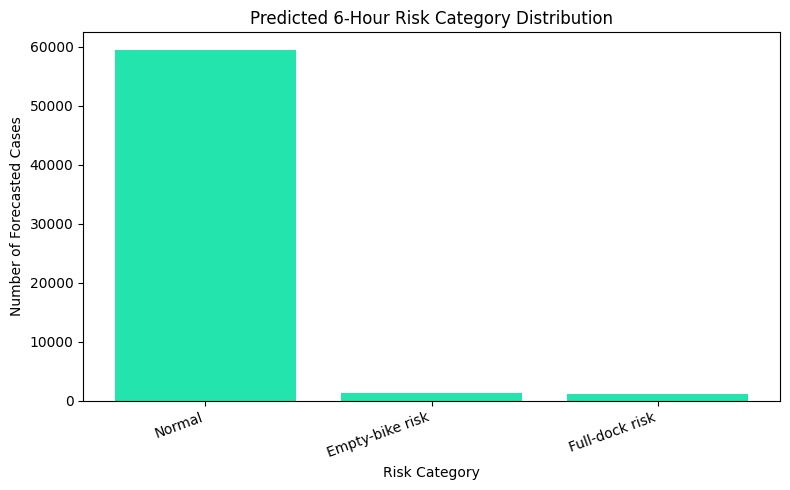

,Rank,ID,NAME,Empty_Bike_Risk_Cases,Full_Dock_Risk_Cases,Both_Side_Pressure_Cases,Average_Predicted_Bikes_6h,Average_Predicted_Empty_Docks_6h,Records,Total_Risk_Cases
0,1,27,New Quay Prom / Harbour Esp - Docklands,591,1,0,5.888844,20.961879,1255,592
1,2,23,Yarra's Edge - River Esp / Yarra River - Dockl...,8,111,0,6.797801,4.035469,1253,119
2,3,40,Rod Laver Arena - Batman Ave / Swan St - City,116,0,0,6.791081,15.949929,1256,116
3,4,51,ANZ - Collins St - Docklands,112,0,0,5.742946,13.065418,1232,112
4,5,10,St Paul's Cathedral - Swanston St / Flinders S...,4,96,0,6.632474,4.244496,1249,100
5,6,38,Aquarium - Kings Way / Flinders St - City,8,77,0,6.805827,4.161603,1259,85
6,7,4,Federation Square - Flinders St / Swanston St ...,0,82,0,17.094793,9.445493,1241,82
7,8,47,VCAM - St Kilda Rd / Southbank Blvd - Southbank,42,32,0,5.539643,5.354968,1233,74
8,9,9,RMIT - Swanston St / Franklin St - City,55,15,0,3.007765,4.156871,1247,70
9,10,17,Yarra's Point - Lorimer St / Yarra River - Doc...,6,62,0,8.204025,6.716166,1220,68


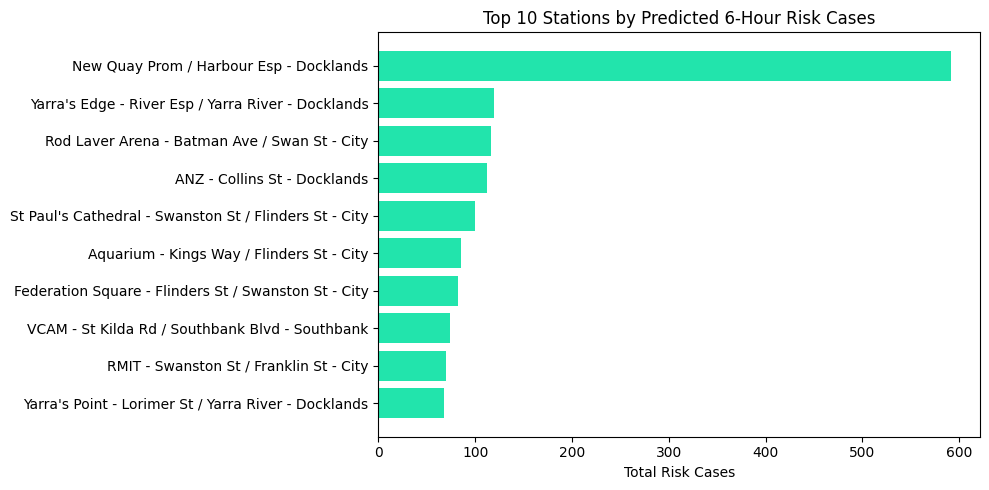

In [17]:
# ============================================================
# 16. Operational risk prioritisation
# ============================================================


risk_df = final_prediction_df.copy()
cap = pd.to_numeric(risk_df["total_docks_est"], errors="coerce").replace(0, np.nan)

# Capacity-aware threshold where possible; fixed threshold fallback for invalid capacity.
empty_bike_threshold = (0.10 * cap).fillna(2)
full_dock_threshold = (0.10 * cap).fillna(2)

risk_df["empty_bike_risk"] = risk_df["pred_bikes_6h"] <= empty_bike_threshold
risk_df["full_dock_risk"] = risk_df["pred_empty_docks_6h"] <= full_dock_threshold

risk_df["risk_category"] = np.select(
    [
        risk_df["empty_bike_risk"] & risk_df["full_dock_risk"],
        risk_df["empty_bike_risk"],
        risk_df["full_dock_risk"],
    ],
    ["Both-side pressure", "Empty-bike risk", "Full-dock risk"],
    default="Normal"
)

risk_summary = risk_df["risk_category"].value_counts().rename_axis("Risk Category").reset_index(name="Number of Forecasted Cases")
risk_summary["Percentage"] = (risk_summary["Number of Forecasted Cases"] / risk_summary["Number of Forecasted Cases"].sum() * 100).round(2)
risk_summary.to_csv(TABLE_DIR / "risk_forecast_summary.csv", index=False)

# Risk category distribution
display_head(risk_summary, 10)

plt.figure(figsize=(8, 5))
plt.bar(risk_summary["Risk Category"], risk_summary["Number of Forecasted Cases"], color=PRIMARY_COLOR)
plt.title("Predicted 6-Hour Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Forecasted Cases")
plt.xticks(rotation=20, ha="right")
save_fig(FIGURE_DIR / "risk_category_distribution.png")

# Top risky stations.
risk_station_group_cols = [station_id_col]
if station_name_col is not None and station_name_col in risk_df.columns:
    risk_station_group_cols.append(station_name_col)

top_risky = risk_df.groupby(risk_station_group_cols, as_index=False).agg(
    Empty_Bike_Risk_Cases=("empty_bike_risk", "sum"),
    Full_Dock_Risk_Cases=("full_dock_risk", "sum"),
    Both_Side_Pressure_Cases=("risk_category", lambda s: int((s == "Both-side pressure").sum())),
    Average_Predicted_Bikes_6h=("pred_bikes_6h", "mean"),
    Average_Predicted_Empty_Docks_6h=("pred_empty_docks_6h", "mean"),
    Records=("hour_ts", "count"),
)

top_risky["Total_Risk_Cases"] = (
    top_risky["Empty_Bike_Risk_Cases"] +
    top_risky["Full_Dock_Risk_Cases"] +
    top_risky["Both_Side_Pressure_Cases"]
)
top_risky = top_risky.sort_values("Total_Risk_Cases", ascending=False).reset_index(drop=True)
top_risky.insert(0, "Rank", np.arange(1, len(top_risky) + 1))
top_risky.to_csv(TABLE_DIR / "top_risky_stations.csv", index=False)

# Top risky stations
display_head(top_risky.head(15), 15)

plot_risky = top_risky.head(10).copy()
risk_label_col = station_name_col if station_name_col is not None and station_name_col in plot_risky.columns else station_id_col
plt.figure(figsize=(10, 5))
plt.barh(plot_risky[risk_label_col].astype(str), plot_risky["Total_Risk_Cases"], color=PRIMARY_COLOR)
plt.gca().invert_yaxis()
plt.title("Top 10 Stations by Predicted 6-Hour Risk Cases")
plt.xlabel("Total Risk Cases")
save_fig(FIGURE_DIR / "top_risky_stations.png")

# Save detailed risk predictions.
risk_df.to_csv(TABLE_DIR / "detailed_risk_predictions.csv", index=False)


<p class="usecase-subsection-header">17. Final conclusion and future work</p>

This final notebook consolidates the project into an end-to-end urban bike-sharing demand prediction pipeline. The project first builds non-graph multi-horizon baselines for bike availability and empty dock availability. It then constructs a distance-based station graph and creates graph-derived neighbour features so each station prediction can use nearby station conditions.

The final outputs support operational decision-making by identifying predicted empty-bike risk, full-dock risk, high-pressure stations, and stations where prediction error is higher.

Future work can extend this project with a full Graph Neural Network, LSTM or temporal attention model, hyperparameter tuning, graph embedding optimisation, real-time dashboarding, and live rebalancing recommendations.


In [18]:
# ============================================================
# 17. Final conclusion and artifact summary
# ============================================================


artifact_summary = {
    "rows_raw_loaded": int(df_raw.shape[0]),
    "rows_hourly": int(hourly.shape[0]),
    "number_of_stations": int(hourly[station_id_col].nunique()),
    "date_min": str(hourly["hour_ts"].min()),
    "date_max": str(hourly["hour_ts"].max()),
    "graph_nodes": graph_stats["nodes"],
    "graph_edges": graph_stats["edges"],
    "selected_models": selected_summary.to_dict(orient="records"),
    "risk_summary": risk_summary.to_dict(orient="records"),
    "tables_folder": str(TABLE_DIR),
    "figures_folder": str(FIGURE_DIR),
}

with open(OUTPUT_DIR / "final_artifact_summary.json", "w", encoding="utf-8") as f:
    json.dump(artifact_summary, f, indent=2)

print("================ FINAL ARTIFACT SUMMARY ================")
print("Rows loaded:", artifact_summary["rows_raw_loaded"])
print("Hourly rows:", artifact_summary["rows_hourly"])
print("Stations:", artifact_summary["number_of_stations"])
print("Date range:", artifact_summary["date_min"], "to", artifact_summary["date_max"])
print("Graph nodes:", artifact_summary["graph_nodes"])
print("Graph edges:", artifact_summary["graph_edges"])
print("\nSelected model summary:")
print(selected_summary.to_string(index=False))
print("\nRisk summary:")
print(risk_summary.to_string(index=False))
print("\nSaved tables folder:", TABLE_DIR)
print("Saved figures folder:", FIGURE_DIR)
print("========================================================")


================ FINAL ARTIFACT SUMMARY ================
Rows loaded: 1000000
Hourly rows: 742153
Stations: 52
Date range: 2015-04-22 12:00:00 to 2018-09-04 10:00:00
Graph nodes: 52
Graph edges: 172

Selected model summary:
        Target Selected Model      MAE     RMSE       R2
      Bikes 6h  Random Forest 1.376982 2.111666 0.858256
Empty Docks 6h  Random Forest 1.380072 2.114649 0.867423

Risk summary:
  Risk Category  Number of Forecasted Cases  Percentage
         Normal                       59480       95.92
Empty-bike risk                        1387        2.24
 Full-dock risk                        1146        1.85

Saved tables folder: d:\Sanaullah\Finalized\outputs_final\tables
Saved figures folder: d:\Sanaullah\Finalized\outputs_final\figures


<div class="usecase-section-header">References and acknowledgements</div>

- City of Melbourne Open Data. *Melbourne bike share station readings 2011–2017*.
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research.
- Hagberg, Schult, and Swart (2008). *Exploring Network Structure, Dynamics, and Function using NetworkX*.
- McKinney (2010). *Data Structures for Statistical Computing in Python*.
- Hunter (2007). *Matplotlib: A 2D Graphics Environment*.

The analysis in this use case is based on the submitted urban bike-sharing demand prediction notebook and has been reformatted to match the official use-case notebook template structure.